# Анализ дохода (Adult Income Dataset)

---

## Введение

В данном проекте рассматривается задача классификации уровня дохода человека на основе его характеристик.

## Описание данных

Датасет содержит информацию о людях, включая возраст, образование, количество рабочих часов и другие признаки. Целевая переменная — уровень дохода (>50K или <=50K).

## Постановка задачи

Цель проекта — построить модель, способную предсказывать, превышает ли доход человека 50K в год.

## Бизнес-контекст

Данная задача может применяться в маркетинге для таргетирования дорогих продуктов на платежеспособную аудиторию.

## Метрика

В качестве основной метрики выбрана precision, так как важно минимизировать ложные срабатывания и избегать показа рекламы пользователям с низким доходом.

---

# Разведочный анализ данных (EDA)

На этапе разведочного анализа данных (EDA) необходимо понять структуру данных, проверить наличие пропусков, оценить баланс классов и выявить возможные зависимости между признаками и целевой переменной.

## Импорт библиотек

In [80]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, roc_auc_score

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

## Загрузка данных

In [2]:
df = pd.read_csv("adult.csv")

## Первичный обзор данных

In [3]:
df.head(5)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [5]:
df.shape

(48842, 15)

Датасет содержит **48842** объектов и **15** признаков. Признаки представлены как числовыми, так и категориальными переменными.

In [6]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(52)

### Обработка скрытых пропусков

In [9]:
(df == '?').sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [10]:
df = df.replace('?', 'Unknown')

В датасете отсутствуют явные пропуски, однако в некоторых категориальных признаках присутствуют значения "?", которые фактически являются скрытыми пропусками.

Наибольшее количество таких значений наблюдается в признаках workclass, occupation и native-country.

Для дальнейшей работы эти значения были заменены на категорию "Unknown".

---

## Распределение данных

### Target

In [11]:
target = df['income'].value_counts(normalize = True) * 100
target

income
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64

<Axes: xlabel='income'>

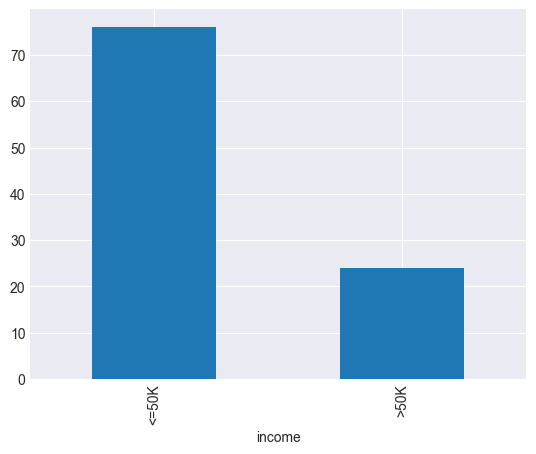

In [12]:
target.plot(kind = 'bar')

**Вывод**

Анализ целевой переменной `income` показывает, что в наборе данных подавлющее большинство людей имеют заработную плату меньше или равную 50К.

Доля людей, имеющих высокую ЗП, составялет около 24% от общего количества людей, представленных в датасете.

Таким образом, наблюдается **дисбаланс классов**, при котором класс ЗП <=50К значительно преобладает над классом ЗП >50K

## Числовые признаки

### Age

Text(0.5, 1.0, 'Распределение возраста')

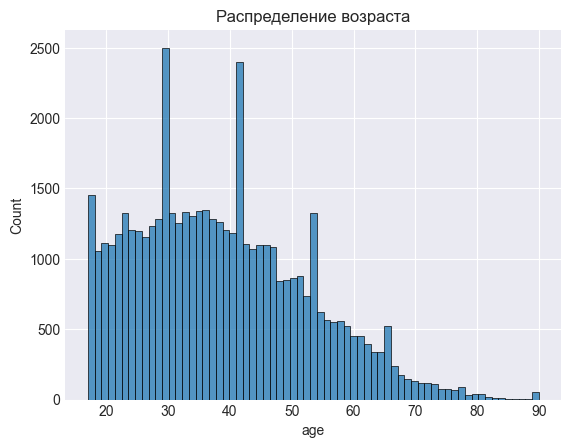

In [13]:
sns.histplot(df['age'])
plt.title('Распределение возраста')

**Вывод**

Распределение возраста смещено вправо: большинство наблюдений сосредоточено в диапазоне 20–50 лет, при этом пожилые люди представлены значительно реже.

Подобное распределение указывает на то, что основная часть выборки состоит из людей трудоспособного возраста, что важно учитывать при анализе данных.

### Hours per week

Text(0.5, 1.0, 'Распределение рабочего времени')

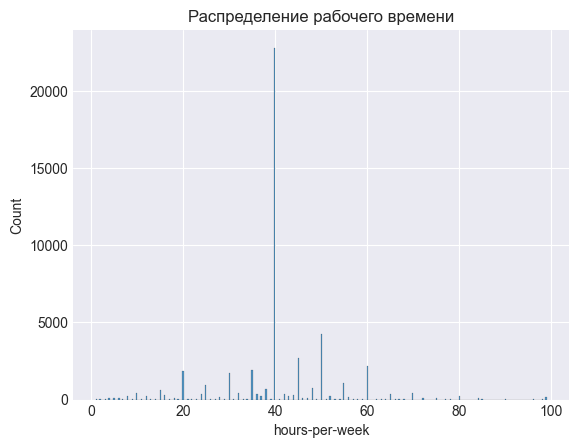

In [14]:
sns.histplot(df['hours-per-week'])
plt.title('Распределение рабочего времени')

**Вывод**

Распределение рабочего времени имеет выраженный пик около 40 часов в неделю, что соответствует стандартной полной занятости. Большинство наблюдений сосредоточено в диапазоне 35–45 часов.

При этом присутствуют редкие значения на крайних участках (около 0 и свыше 80–100 часов), которые можно рассматривать как выбросы.

Относительно узкий диапазон значений может ограничивать информативность признака для модели.

### Capital Gain

Text(0.5, 1.0, 'Распределение прироста')

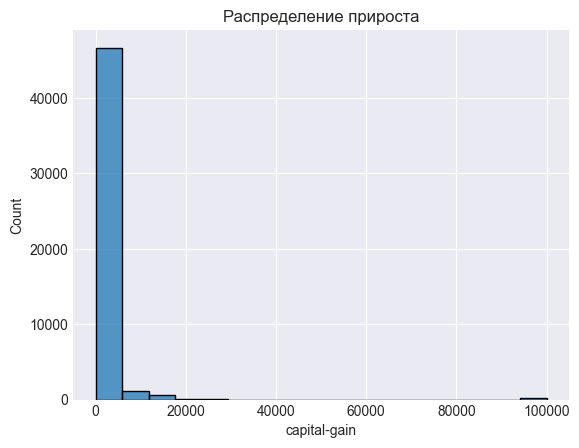

In [15]:
sns.histplot(df['capital-gain'])
plt.title('Распределение прироста')

**Вывод**

Распределение признака capital-gain сильно смещено вправо: большинство наблюдений имеют нулевые или близкие к нулю значения, при этом встречаются редкие случаи с высоким приростом капитала.

Наличие большого количества нулевых значений и редких выбросов может создавать дисбаланс в признаке и влиять на обучение модели.

### Capital Loss

Text(0.5, 1.0, 'Распределение убытков')

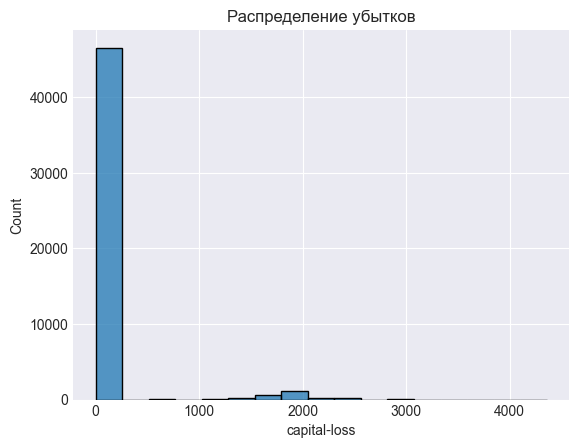

In [16]:
sns.histplot(df['capital-loss'])
plt.title('Распределение убытков')

**Вывод**

Распределение признака capital-loss смещено вправо: большинство наблюдений имеют нулевые или небольшие значения, при этом присутствуют редкие случаи с высокими значениями убытков.

Преобладание нулевых значений может снижать информативность признака и требует внимания при моделировании.

## Категориальные признаки

### Education

Text(0.5, 1.0, 'Распределение образования')

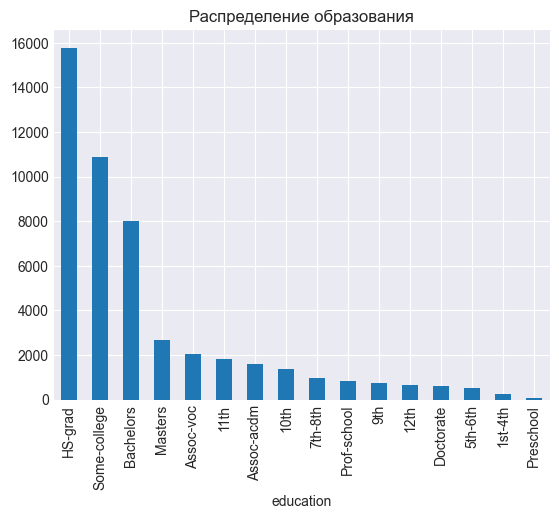

In [17]:
df['education'].value_counts().plot(kind= 'bar')
plt.title('Распределение образования')

**Вывод**

Распределение уровня образования неравномерное: наибольшую долю составляют категории HS-grad, Some-college и Bachelors, тогда как более высокие уровни образования (Masters, Doctorate, Prof-school) встречаются значительно реже.

Подобный дисбаланс категорий может влиять на обучение модели, так как редкие категории представлены ограниченно.



### Workclass

Text(0.5, 1.0, 'Распределение рабочего класса')

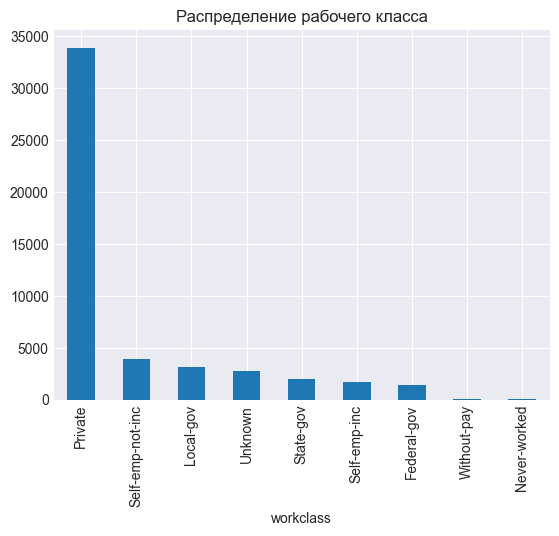

In [18]:
df['workclass'].value_counts().plot(kind = 'bar')

plt.title('Распределение рабочего класса')

**Вывод**

Распределение признака workclass неравномерное: большинство наблюдений относится к категории Private, тогда как остальные категории представлены значительно слабее, а некоторые (например, Without-pay и Never-worked) встречаются крайне редко.

Наличие доминирующей категории и редких значений может влиять на устойчивость модели.

### Occupation

Text(0.5, 1.0, 'Распределение занятий')

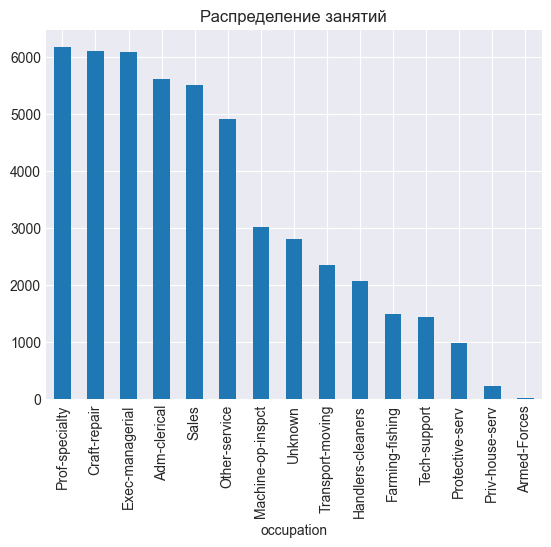

In [19]:
df['occupation'].value_counts().plot(kind = 'bar')

plt.title('Распределение занятий')

**Вывод**

Распределение признака occupation неравномерное: наиболее часто встречаются категории Prof-specialty и Exec-managerial, тогда как некоторые категории (например, Priv-house-serv, Armed-Forces) представлены крайне редко.

Редкие категории могут быть менее информативными для модели из-за ограниченного числа наблюдений.

### Marital-status

Text(0.5, 1.0, 'Распределение семейного положения')

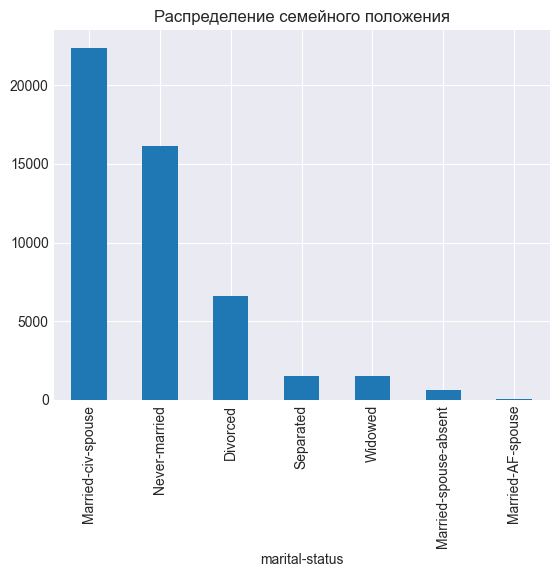

In [20]:
df['marital-status'].value_counts().plot(kind = 'bar')

plt.title('Распределение семейного положения')

**Вывод**

Распределение семейного положения неравномерное: наибольшую долю составляют категории Married-civ-spouse и Never-married, тогда как остальные категории представлены значительно реже.

Наличие дисбаланса категорий может влиять на обучение модели и требует учета при анализе данных.

---

## Числовые признаки vs target

### Age

<Axes: xlabel='income', ylabel='age'>

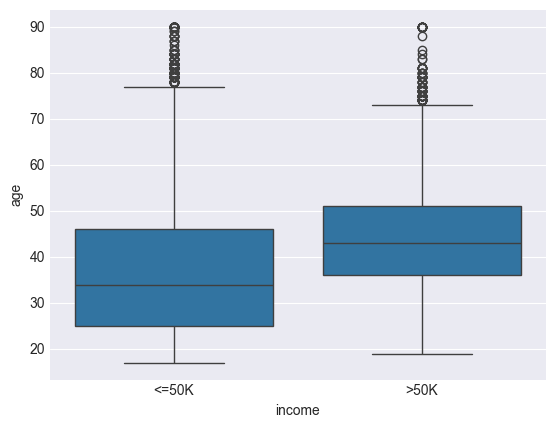

In [21]:
sns.boxplot(x='income', y='age', data=df)

**Вывод**

Люди с доходом >50K в среднем старше, чем люди с доходом <=50K: медиана возраста в данной группе заметно выше.

Это указывает на наличие зависимости между возрастом и уровнем дохода, что может быть связано с накоплением опыта.

Таким образом, возраст может играть значимую роль в определении уровня дохода и быть полезным признаком для модели.

### Educational-num

<Axes: xlabel='income', ylabel='educational-num'>

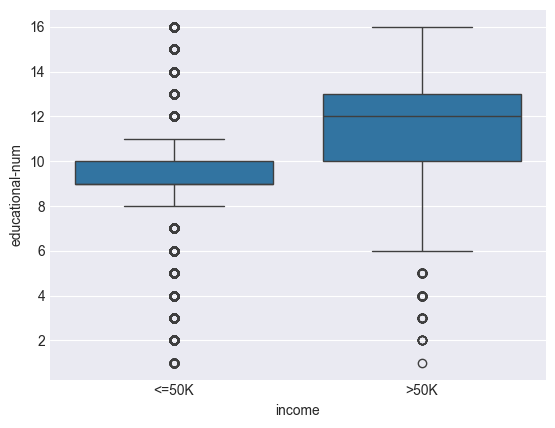

In [22]:
sns.boxplot(x='income', y='educational-num', data=df)

**Вывод**

Люди с доходом >50K в среднем имеют более высокий уровень образования (educational-num), чем люди с доходом <=50K.

Это указывает на наличие положительной зависимости между уровнем образования и доходом.

Следовательно, уровень образования может выступать одним из ключевых факторов при прогнозировании дохода.

### Hours-per-week

<Axes: xlabel='income', ylabel='hours-per-week'>

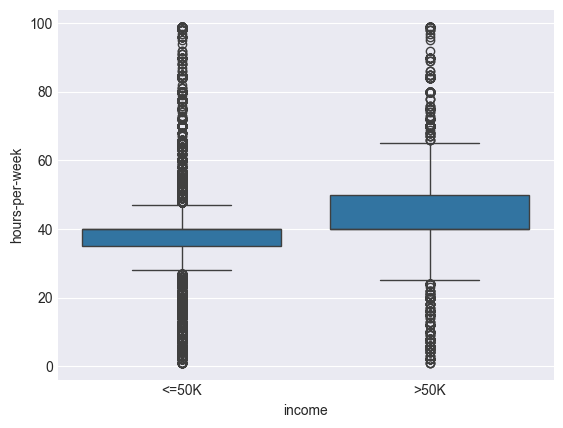

In [23]:
sns.boxplot(x='income', y='hours-per-week', data=df)

**Вывод**

Признак hours-per-week не демонстрирует выраженного различия между группами дохода: медианные значения в обеих категориях находятся около 40 часов, а распределения значительно пересекаются.

Несмотря на то, что среди людей с доходом >50K немного чаще встречаются более высокие значения рабочего времени, данная зависимость выражена слабо.

Таким образом, данный признак, вероятно, обладает ограниченной предсказательной способностью для модели.

### Capital-gain

<Axes: xlabel='income'>

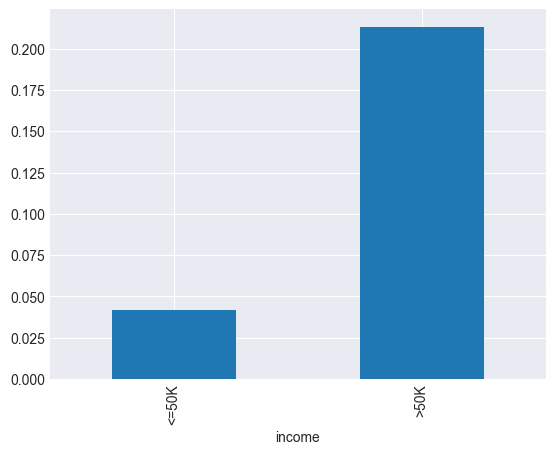

In [24]:
(df['capital-gain'] > 0).groupby(df['income']).mean().plot(kind='bar')

**Вывод**

Наличие ненулевого значения признака capital-gain значительно чаще встречается у людей с доходом >50K.

Доля таких наблюдений в группе >50K существенно выше, чем в группе <=50K, что указывает на сильную связь между дополнительным доходом и общим уровнем дохода.

Следовательно, данный признак является одним из наиболее значимых для модели и может существенно влиять на предсказание.

### Capital-loss

<Axes: xlabel='income'>

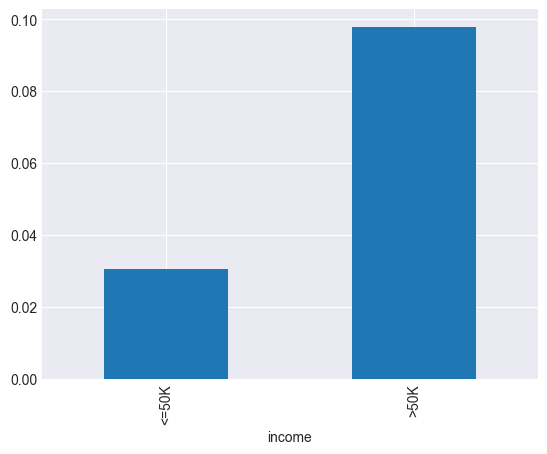

In [25]:
(df['capital-loss'] > 0).groupby(df['income']).mean().plot(kind='bar')

**Вывод**

Ненулевые значения признака capital-loss встречаются чаще у людей с доходом >50K по сравнению с группой <=50K.

Однако доля таких наблюдений остаётся небольшой, и зависимость между признаком и уровнем дохода выражена слабо, особенно по сравнению с capital-gain.

Таким образом, данный признак может иметь ограниченную предсказательную ценность для модели.

## Категориальные признаки vs target

### Workclass

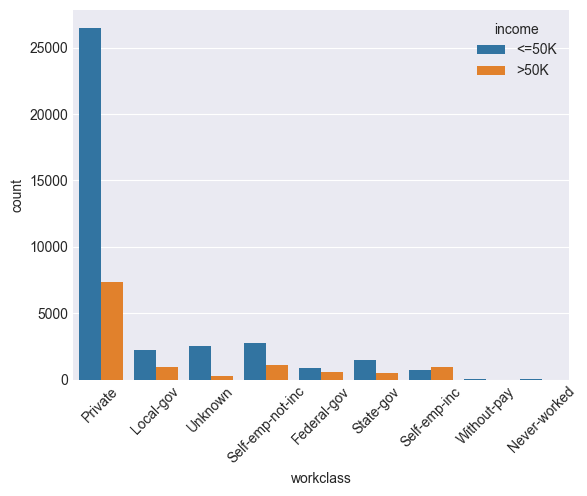

In [62]:
sns.countplot(x='workclass', hue='income', data=df)
plt.xticks(rotation=45);

**Вывод**

В категории Private преобладают люди с доходом <=50K, что связано с её доминированием в данных.

При этом в категории Self-emp-inc доля людей с доходом >50K заметно выше по сравнению с другими категориями, тогда как категории Without-pay и Never-worked практически не содержат наблюдений с высоким доходом.

Это указывает на наличие зависимости между типом занятости и уровнем дохода, поэтому признак workclass может быть полезен для модели.

### Education

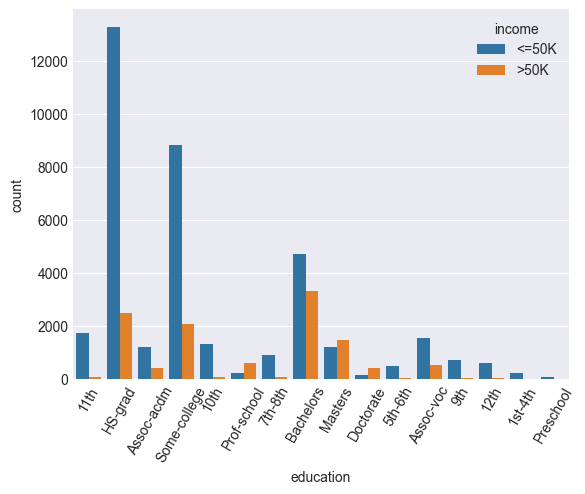

In [63]:
sns.countplot(x='education', hue='income', data=df)
plt.xticks(rotation=60);

**Вывод**

В категориях с более низким уровнем образования (например, HS-grad, 11th) преобладают люди с доходом <=50K.

С повышением уровня образования (Bachelors, Masters, Doctorate) доля людей с доходом >50K заметно увеличивается.

Это указывает на положительную зависимость между уровнем образования и доходом, поэтому данный признак является важным для модели.

### Occupation

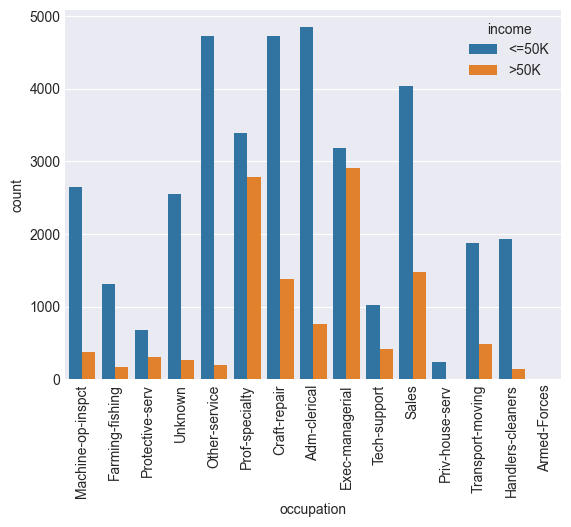

In [64]:
sns.countplot(x='occupation', hue='income', data=df)
plt.xticks(rotation= 90);

**Вывод**

В большинстве категорий occupation преобладают люди с доходом <=50K.

При этом в категориях Prof-specialty и Exec-managerial доля людей с доходом >50K заметно выше по сравнению с другими профессиями, тогда как в Priv-house-serv и Armed-Forces практически отсутствуют наблюдения с высоким доходом.

Это указывает на выраженную зависимость между родом занятий и уровнем дохода, поэтому данный признак является значимым для модели.

### Marital-status

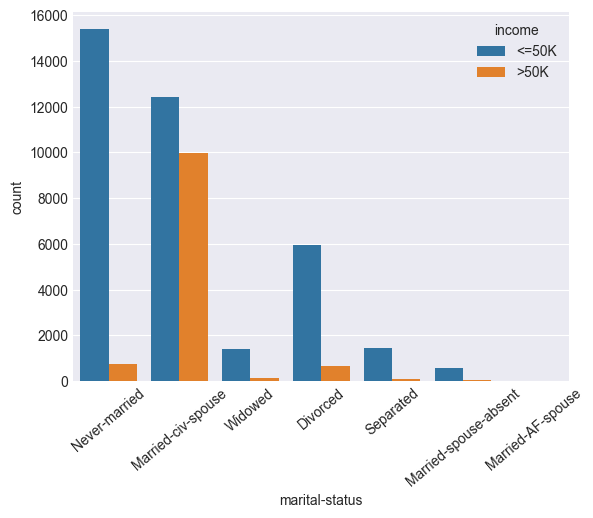

In [65]:
sns.countplot(x='marital-status', hue='income', data=df)
plt.xticks(rotation=40);

**Вывод**

В большинстве категорий marital-status преобладают люди с доходом <=50K.

При этом в категории Married-civ-spouse доля людей с доходом >50K заметно выше по сравнению с другими семейными положениями, тогда как в категориях Married-spouse-absent и Married-AF-spouse практически отсутствуют наблюдения с высоким доходом.

Это указывает на выраженную зависимость между семейным положением и уровнем дохода, поэтому данный признак является значимым для модели.

---

# Итоговый вывод по EDA

В ходе разведочного анализа данных было выявлено, что признаки education, occupation, marital-status и capital-gain демонстрируют выраженную зависимость с уровнем дохода и могут существенно влиять на предсказание.

В то же время признаки hours-per-week и capital-loss показали слабую связь с целевой переменной и обладают ограниченной предсказательной способностью.

Таким образом, в данных присутствуют как сильные, так и слабые признаки, что необходимо учитывать при построении модели.

---

## Подготовка данных для моделирования

In [31]:
df_ml = df.drop(columns=['fnlwgt'])

In [32]:
X = df_ml.drop('income', axis=1)
y = df_ml['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join='left', axis=1)

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [81]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Обучение моделей

### Логистическая регрессия

In [85]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, y_train);

In [86]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.95      0.80      0.87      7479
        >50K       0.57      0.85      0.68      2290

    accuracy                           0.81      9769
   macro avg       0.76      0.83      0.78      9769
weighted avg       0.86      0.81      0.83      9769



In [87]:
print(model.score(X_train_scaled, y_train))
print(model.score(X_test_scaled, y_test))

0.80892176183042
0.8145153035111066


Модель логистической регрессии показывает стабильные результаты без признаков переобучения: значения accuracy на обучающей и тестовой выборках практически совпадают.

Модель демонстрирует высокий recall для класса >50K, однако precision остаётся умеренным, что приводит к значительному числу ложных срабатываний.

Это связано с тем, что логистическая регрессия является линейной моделью и не способна в полной мере уловить сложные зависимости в данных.

Таким образом, несмотря на стабильность, модель уступает более сложным алгоритмам по ключевой метрике precision и не является оптимальной для решения данной задачи.

### Дерево решений

In [69]:
model_dt = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
model_dt.fit(X_train, y_train);

In [75]:
y_pred_dt = model_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

       <=50K       0.95      0.77      0.85      7479
        >50K       0.54      0.87      0.66      2290

    accuracy                           0.80      9769
   macro avg       0.74      0.82      0.76      9769
weighted avg       0.85      0.80      0.81      9769



In [44]:
print(model_dt.score(X_train, y_train))
print(model_dt.score(X_test, y_test))

0.7915440329639393
0.7951683898044836


Дерево решений не демонстрирует признаков переобучения: значения accuracy на обучающей и тестовой выборках близки, что связано с ограничением глубины дерева.

Модель показывает высокий recall для класса >50K, однако precision остаётся низким, что приводит к значительному числу ложных срабатываний.

Несмотря на простоту и интерпретируемость, дерево решений уступает ансамблевым методам по качеству предсказаний.

Таким образом, данная модель не является оптимальной для решения поставленной задачи.

### Случайный лес

In [70]:
model_rf = RandomForestClassifier(max_depth=5, class_weight='balanced')
model_rf.fit(X_train, y_train);

In [74]:
y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

       <=50K       0.95      0.72      0.82      7479
        >50K       0.49      0.87      0.63      2290

    accuracy                           0.75      9769
   macro avg       0.72      0.80      0.72      9769
weighted avg       0.84      0.75      0.77      9769



In [49]:
print(model_rf.score(X_train, y_train))
print(model_rf.score(X_test, y_test))

0.7406905023929568
0.7484901218139011


Модель случайного леса не демонстрирует признаков переобучения: значения accuracy на обучающей и тестовой выборках близки.

Однако модель показывает низкое значение precision для класса >50K при высоком recall, что приводит к большому количеству ложных срабатываний.

Вероятно, это связано с ограничением глубины деревьев (max_depth=5), что делает модель слишком простой и снижает её способность выявлять сложные зависимости в данных.

Таким образом, случайный лес в данной конфигурации уступает другим моделям по качеству предсказаний и не является оптимальным выбором.

### Градиентный бустинг

In [71]:
model_gb = GradientBoostingClassifier(learning_rate=0.1,
                                      random_state=42,
                                      max_depth=3,
                                      n_estimators=100)
model_gb.fit(X_train, y_train);

In [53]:
y_pred_gb = model_gb.predict(X_test)
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

       <=50K       0.89      0.95      0.92      7479
        >50K       0.80      0.62      0.70      2290

    accuracy                           0.87      9769
   macro avg       0.84      0.79      0.81      9769
weighted avg       0.87      0.87      0.87      9769



In [54]:
print(model_gb.score(X_train, y_train))
print(model_gb.score(X_test, y_test))

0.8669157730402068
0.8737844201044119


Градиентный бустинг демонстрирует стабильные результаты без признаков переобучения: значения accuracy на обучающей и тестовой выборках близки.

Модель показывает наилучшее значение precision для класса >50K по сравнению с другими моделями, что позволяет значительно снизить количество ложных срабатываний.

При этом recall несколько ниже, однако это является допустимым компромиссом в рамках поставленной задачи, где приоритетом является точность предсказаний.

Таким образом, градиентный бустинг является наиболее подходящей моделью для решения данной задачи.

## Сравнение моделей

In [89]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Precision (>50K)': [0.57, 0.54, 0.49, 0.80],
    'Recall (>50K)': [0.85, 0.87, 0.87, 0.62],
    'Accuracy': [0.81, 0.80, 0.75, 0.87]
})

results.sort_values(by='Precision (>50K)', ascending=False)

,Model,Precision (>50K),Recall (>50K),Accuracy
3,Gradient Boosting,0.80,0.62,0.87
0,Logistic Regression,0.57,0.85,0.81
1,Decision Tree,0.54,0.87,0.80
2,Random Forest,0.49,0.87,0.75


Из таблицы видно, что градиентный бустинг значительно превосходит остальные модели по метрике precision.

Все рассмотренные модели показали различное качество предсказаний.

Логистическая регрессия и дерево решений продемонстрировали высокий recall, однако уступают по precision, что приводит к большому количеству ложных срабатываний.

Случайный лес показал стабильные результаты, однако его precision оказался ниже, чем у других моделей.

Градиентный бустинг продемонстрировал наилучшее значение precision при сохранении приемлемого уровня recall, что соответствует требованиям задачи.

Таким образом, градиентный бустинг был выбран в качестве итоговой модели, так как он обеспечивает наилучшее значение precision, что соответствует бизнес-задаче минимизации ложных срабатываний.

## Выбор итоговой модели

По результатам сравнения моделей наилучшее значение precision показал градиентный бустинг при сохранении приемлемого уровня recall.

С учётом того, что в задаче приоритетом является минимизация ложных срабатываний, именно градиентный бустинг был выбран в качестве итоговой модели.

## Настройка порога классификации

In [55]:
y_prob_gb = model_gb.predict_proba(X_test)[:, 1]

In [56]:
y_prob_gb03 = (y_prob_gb > 0.3)
y_prob_gb03 = np.where(y_prob_gb03, '>50K', '<=50K')
print(classification_report(y_test, y_prob_gb03))

              precision    recall  f1-score   support

       <=50K       0.94      0.86      0.90      7479
        >50K       0.64      0.81      0.72      2290

    accuracy                           0.85      9769
   macro avg       0.79      0.84      0.81      9769
weighted avg       0.87      0.85      0.86      9769



In [57]:
y_prob_gb04 = (y_prob_gb > 0.4)
y_prob_gb04 = np.where(y_prob_gb04, '>50K', '<=50K')
print(classification_report(y_test, y_prob_gb04))

              precision    recall  f1-score   support

       <=50K       0.91      0.92      0.92      7479
        >50K       0.73      0.71      0.72      2290

    accuracy                           0.87      9769
   macro avg       0.82      0.82      0.82      9769
weighted avg       0.87      0.87      0.87      9769



In [58]:
y_prob_gb06 = (y_prob_gb > 0.6)
y_prob_gb06 = np.where(y_prob_gb06, '>50K', '<=50K')
print(classification_report(y_test, y_prob_gb06))

              precision    recall  f1-score   support

       <=50K       0.87      0.97      0.92      7479
        >50K       0.84      0.54      0.66      2290

    accuracy                           0.87      9769
   macro avg       0.86      0.75      0.79      9769
weighted avg       0.87      0.87      0.86      9769



**Вывод**

В ходе экспериментов с различными значениями порога классификации (0.3, 0.4, 0.6) было выявлено, что снижение порога увеличивает recall, но приводит к росту числа ложных срабатываний, тогда как его повышение увеличивает precision, но снижает способность модели выявлять объекты класса >50K.

Базовый порог 0.5 обеспечивает наилучший баланс между precision и recall и соответствует требованиям задачи, где приоритетом является точность предсказаний.

Таким образом, в качестве итогового был выбран порог 0.5.

## Итоговые выводы

В рамках проекта была решена задача классификации уровня дохода пользователей на основе их характеристик.

В ходе разведочного анализа данных были выявлены признаки, оказывающие наибольшее влияние на уровень дохода, такие как образование, род занятий, семейное положение и наличие дополнительного дохода.

Были обучены и сравнены несколько моделей машинного обучения. Наилучшие результаты показал градиентный бустинг, обеспечивший высокое значение precision при приемлемом уровне recall.

Дополнительная настройка порога классификации позволила адаптировать модель под бизнес-задачу, минимизируя количество ложных срабатываний.

Итоговая модель может быть использована для таргетирования маркетинговых предложений на платежеспособную аудиторию.

## Ограничения и возможные улучшения

Следует учитывать, что модель обучена на ограниченном наборе признаков, и её качество может быть улучшено за счёт добавления новых данных или более детальной обработки существующих признаков.

Также возможно дальнейшее улучшение результатов за счёт более глубокой настройки гиперпараметров моделей или использования более сложных алгоритмов.

Кроме того, модель может быть дополнительно адаптирована под конкретные бизнес-требования за счёт изменения порога классификации.